In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# importing data
df = pd.read_csv("Airplane accidents severity.csv")

In [3]:
# first few rows.
df.head()

,Severity,Safety_Score,Days_Since_Inspection,Total_Safety_Complaints,Control_Metric,Turbulence_In_gforces,Cabin_Temperature,Accident_Type_Code,Max_Elevation,Violations,Adverse_Weather_Metric,Accident_ID
0,Minor_Damage_And_Injuries,49.223744,14,22,71.285324,0.272118,78.04,2,31335.47682,3,0.424352,7570
1,Minor_Damage_And_Injuries,62.465753,10,27,72.288058,0.423939,84.54,2,26024.71106,2,0.352350,12128
2,Significant_Damage_And_Fatalities,63.059361,13,16,66.362808,0.322604,78.86,7,39269.05393,3,0.003364,2181
3,Significant_Damage_And_Serious_Injuries,48.082192,11,9,74.703737,0.337029,81.79,3,42771.49920,1,0.211728,5946
4,Significant_Damage_And_Fatalities,26.484018,13,25,47.948952,0.541140,77.16,3,35509.22852,2,0.176883,9054


In [4]:
# columns of the dataset
df.columns

Index(['Severity', 'Safety_Score', 'Days_Since_Inspection',
       'Total_Safety_Complaints', 'Control_Metric', 'Turbulence_In_gforces',
       'Cabin_Temperature', 'Accident_Type_Code', 'Max_Elevation',
       'Violations', 'Adverse_Weather_Metric', 'Accident_ID'],
      dtype='object')

In [5]:
# information obout the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Severity                 10000 non-null  object 
 1   Safety_Score             10000 non-null  float64
 2   Days_Since_Inspection    10000 non-null  int64  
 3   Total_Safety_Complaints  10000 non-null  int64  
 4   Control_Metric           10000 non-null  float64
 5   Turbulence_In_gforces    10000 non-null  float64
 6   Cabin_Temperature        10000 non-null  float64
 7   Accident_Type_Code       10000 non-null  int64  
 8   Max_Elevation            10000 non-null  float64
 9   Violations               10000 non-null  int64  
 10  Adverse_Weather_Metric   10000 non-null  float64
 11  Accident_ID              10000 non-null  int64  
dtypes: float64(6), int64(5), object(1)
memory usage: 937.6+ KB


In [6]:
# missing observations
df.isna().sum()

Severity                   0
Safety_Score               0
Days_Since_Inspection      0
Total_Safety_Complaints    0
Control_Metric             0
Turbulence_In_gforces      0
Cabin_Temperature          0
Accident_Type_Code         0
Max_Elevation              0
Violations                 0
Adverse_Weather_Metric     0
Accident_ID                0
dtype: int64

In [7]:
# Check for Duplicates
print("\n Number of Duplicate Rows:")
print(df.duplicated().sum())


 Number of Duplicate Rows:
0


There are no missing observations in the data.

In [8]:
# Unique Classes in Target
print("\n Unique 'Severity' Labels:")
print(df['Severity'].value_counts(normalize=True)) 


 Unique 'Severity' Labels:
Highly_Fatal_And_Damaging                  0.3049
Significant_Damage_And_Serious_Injuries    0.2729
Minor_Damage_And_Injuries                  0.2527
Significant_Damage_And_Fatalities          0.1695
Name: Severity, dtype: float64


In [9]:
# Drop irrelacant features
df.drop(['Accident_ID'],axis=1,inplace=True)


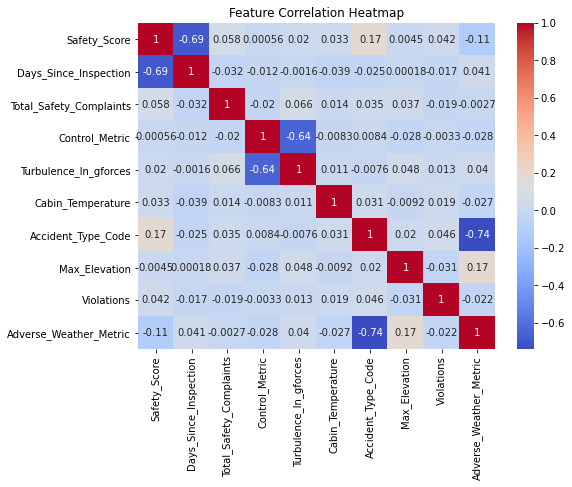

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop(['Severity'], axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

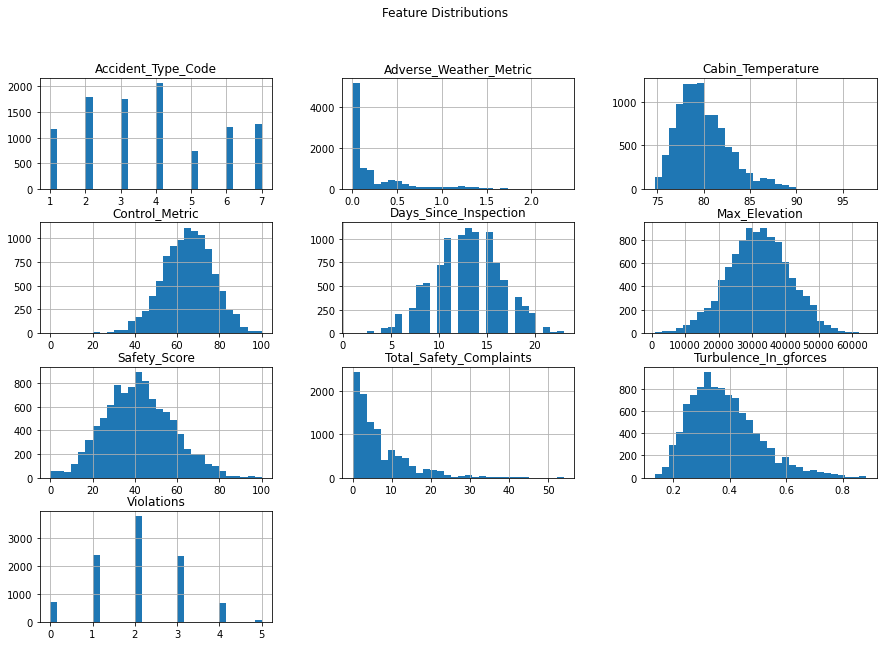

In [11]:
# Distribution of Features
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns
df[numerical_features].hist(figsize=(15, 10), bins=30)
plt.suptitle("Feature Distributions")
plt.show()

In [12]:
# Encode Target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Severity_encoded'] = le.fit_transform(df['Severity'])
print("\n Encoded Target Classes Mapping:")
print(dict(zip(le.classes_, le.transform(le.classes_))))


 Encoded Target Classes Mapping:
{'Highly_Fatal_And_Damaging': 0, 'Minor_Damage_And_Injuries': 1, 'Significant_Damage_And_Fatalities': 2, 'Significant_Damage_And_Serious_Injuries': 3}


In [13]:
df = df.drop('Severity', axis=1)

In [14]:
X = df.drop('Severity_encoded', axis=1)
y = df['Severity_encoded']

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

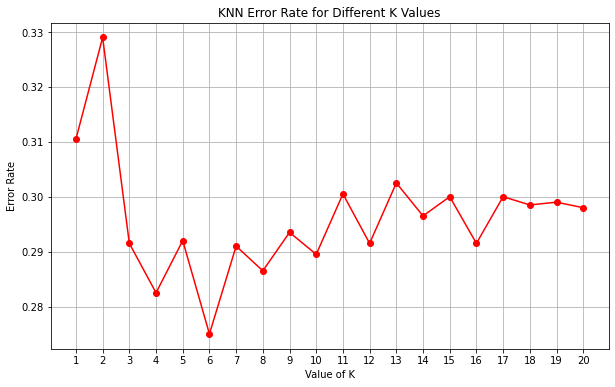


Best K = 6 with Error Rate = 0.2750


In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Different values of K and store error rates
k_range = range(1, 21)
errors = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_k = knn.predict(X_test)
    error = 1 - accuracy_score(y_test, y_pred_k)
    errors.append(error)

# Plot Error vs K
plt.figure(figsize=(10, 6))
plt.plot(k_range, errors, marker='o', color='red')
plt.xticks(k_range)
plt.xlabel('Value of K')
plt.ylabel('Error Rate')
plt.title('KNN Error Rate for Different K Values')
plt.grid(True)
plt.show()

# Best K (lowest error)
optimal_k = k_range[errors.index(min(errors))]
print(f"\nBest K = {optimal_k} with Error Rate = {min(errors):.4f}")


In [18]:
# final model with optimal K
knn_final = KNeighborsClassifier(n_neighbors=optimal_k)
knn_final.fit(X_train, y_train)
y_pred = knn_final.predict(X_test)

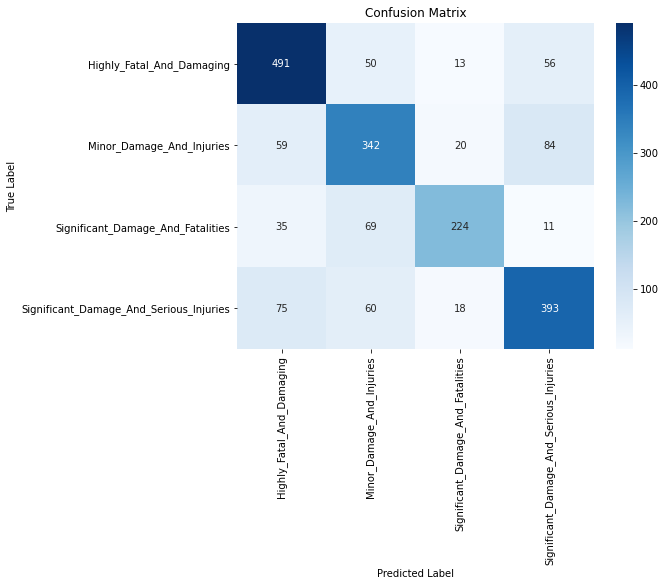


 Classification Report:
                                         precision    recall  f1-score   support

              Highly_Fatal_And_Damaging       0.74      0.80      0.77       610
              Minor_Damage_And_Injuries       0.66      0.68      0.67       505
      Significant_Damage_And_Fatalities       0.81      0.66      0.73       339
Significant_Damage_And_Serious_Injuries       0.72      0.72      0.72       546

                               accuracy                           0.73      2000
                              macro avg       0.73      0.72      0.72      2000
                           weighted avg       0.73      0.72      0.72      2000



In [19]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

In [20]:
# Cross-Validation
from sklearn.model_selection import cross_val_score

# final KNN model with best K = 6
knn_cv = KNeighborsClassifier(n_neighbors=6)

# cross-validation
cv_scores = cross_val_score(knn_cv, X_scaled, y, cv=6, scoring='accuracy')

# Print results
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Average Accuracy Across Folds:", np.mean(cv_scores).round(4))
print("Standard Deviation:", np.std(cv_scores).round(4))

Cross-Validation Accuracy Scores: [0.71205759 0.71025795 0.74565087 0.70845831 0.70048019 0.70468187]
Average Accuracy Across Folds: 0.7136
Standard Deviation: 0.0148
